# Train / Test Split — Used Car Price Prediction

Loads the feature-engineered dataset from `03_feature_engineering.ipynb`, finalizes
the target definition, and produces a single train/test split. No fixed validation
set — validation happens via k-fold cross-validation on the training set during
model comparison and tuning (see `06_model_comparison.ipynb`). The test set is
sealed here and stays untouched until final evaluation.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from sklearn.model_selection import train_test_split
from src.features import add_log_price

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/processed/used_cars_features.csv")
df.shape

(6018, 17)

In [3]:
df = add_log_price(df)
df[['Price', 'Price_log']].describe()

,Price,Price_log
count,6018.000000,6018.000000
mean,9.470243,2.018068
std,11.165926,0.747760
min,0.440000,0.364643
25%,3.500000,1.504077
50%,5.640000,1.893112
75%,9.950000,2.393339
max,160.000000,5.081404


In [4]:
df = df.drop(columns=['Name'])

In [5]:
price_bin = pd.qcut(df['Price'], q=5, labels=False, duplicates='drop')

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=price_bin
)

train_df.shape, test_df.shape

((4814, 17), (1204, 17))

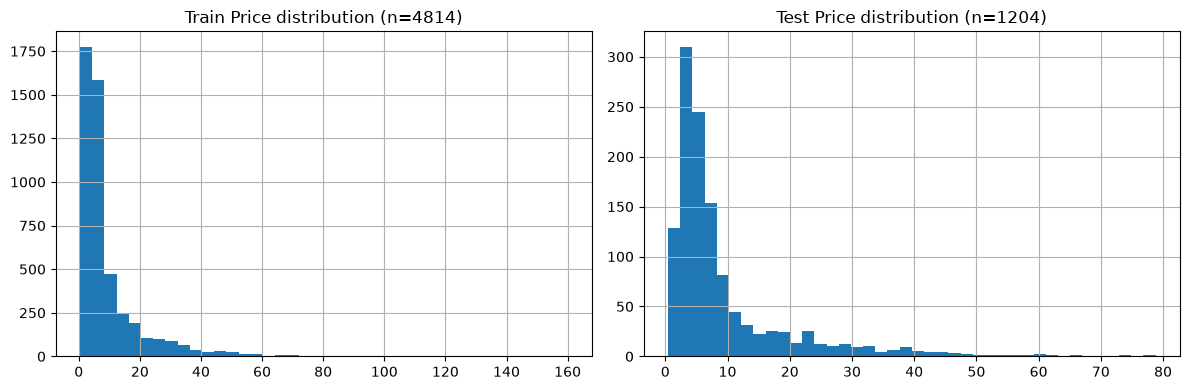

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['Price'].hist(bins=40, ax=axes[0])
axes[0].set_title(f'Train Price distribution (n={len(train_df)})')
test_df['Price'].hist(bins=40, ax=axes[1])
axes[1].set_title(f'Test Price distribution (n={len(test_df)})')
plt.tight_layout()
plt.show()

In [7]:
train_df['Price'].describe()

count    4814.000000
mean        9.533388
std        11.428493
min         0.440000
25%         3.500000
50%         5.615000
75%        10.000000
max       160.000000
Name: Price, dtype: float64

In [8]:
test_df['Price'].describe()

count    1204.000000
mean        9.217766
std        10.048219
min         0.450000
25%         3.525000
50%         5.650000
75%         9.527500
max        78.800000
Name: Price, dtype: float64

In [9]:
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print(f"Train: {train_df.shape[0]} rows | Test: {test_df.shape[0]} rows")

Train: 4814 rows | Test: 1204 rows
